In [1]:
import pandas as pd

df = pd.read_csv("energydata_complete.csv")

print(df.head())
print(df.info())
print(df.describe())

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

In [2]:
print(df.columns)

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')


In [3]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

df.drop('date', axis=1, inplace=True)

In [4]:
print(df.columns)

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2', 'hour', 'day', 'month', 'weekday'],
      dtype='object')


In [5]:
df.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
hour           0
day            0
month          0
weekday        0
dtype: int64

In [6]:
df.fillna(df.mean(), inplace=True)

In [7]:
df = pd.get_dummies(df, columns=['weekday'], drop_first=True)

FEATURE SELECTION

1 Correlation Map

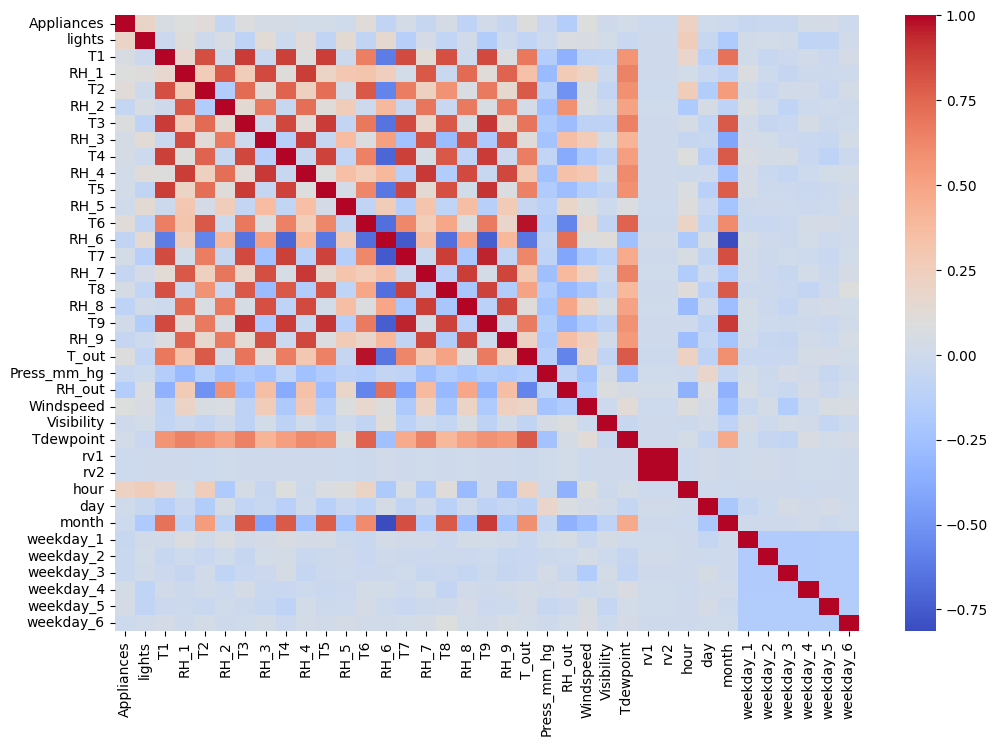

Correlation Features:
 ['hour', 'lights', 'RH_out', 'T2', 'T6', 'T_out', 'RH_8', 'Windspeed', 'RH_1', 'T3']


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()
# Correlation with target
corr = df.corr()["Appliances"].abs().sort_values(ascending=False)

corr_features = corr.drop("Appliances").head(10).index.tolist()
print("Correlation Features:\n", corr_features)

2 Select K best

In [9]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop("Appliances", axis=1)
y = df["Appliances"]

selector = SelectKBest(score_func=f_regression, k=10)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

kbest_features = X.columns[selector.get_support()].tolist()

Index(['lights', 'RH_1', 'T2', 'T3', 'T6', 'RH_8', 'T_out', 'RH_out',
       'Windspeed', 'hour'],
      dtype='object')


3 Random Forest Feature Importance

Feature Importances (Sorted):

hour           0.149966
T3             0.057666
RH_3           0.046987
Press_mm_hg    0.042319
RH_5           0.037695
T8             0.037346
RH_2           0.034751
Tdewpoint      0.031646
RH_1           0.030719
lights         0.030115
RH_7           0.029714
RH_8           0.029073
RH_out         0.028691
RH_4           0.028574
RH_9           0.028563
T5             0.028493
RH_6           0.027657
T2             0.027011
T_out          0.026642
T4             0.026568
T6             0.025631
T7             0.024702
Windspeed      0.023968
Visibility     0.020833
T1             0.020804
T9             0.019940
rv1            0.018316
month          0.017819
rv2            0.017411
day            0.016941
weekday_4      0.004402
weekday_5      0.003869
weekday_1      0.001422
weekday_3      0.001356
weekday_6      0.001350
weekday_2      0.001038
dtype: float64

Top 10 Features:
 ['hour', 'T3', 'RH_3', 'Press_mm_hg', 'RH_5', 'T8', 'RH_2', 'Tdewpoint'

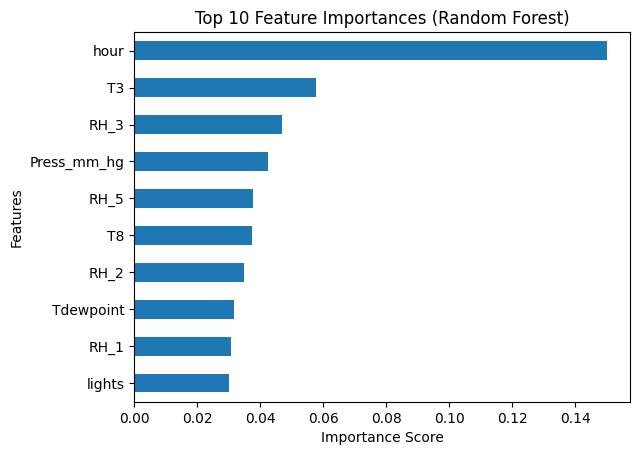

In [10]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Train model
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Convert importances to pandas Series
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Sort values (descending)
importances_sorted = importances.sort_values(ascending=False)

#  Print full sorted importance
print("Feature Importances (Sorted):\n")
print(importances_sorted)

#  Top 10 features list
rf_features = importances_sorted.head(10).index.tolist()
print("\nTop 10 Features:\n", rf_features)

#  Plot graph (horizontal bar chart)
importances_sorted.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [11]:
# Convert to sets
corr_set = set(corr_features)
kbest_set = set(kbest_features)
rf_set = set(rf_features)

# Intersection (common in all 3)
common_features = list(corr_set & kbest_set & rf_set)

# Features appearing in at least 2 methods
two_method_features = list(
    (corr_set & kbest_set) |
    (corr_set & rf_set) |
    (kbest_set & rf_set)
)

print("\nCommon in ALL 3:\n", common_features)
print("\nCommon in at least 2 methods:\n", two_method_features)


Common in ALL 3:
 ['RH_1', 'hour', 'T3', 'lights']

Common in at least 2 methods:
 ['T6', 'T3', 'lights', 'T_out', 'RH_1', 'RH_8', 'T2', 'hour', 'RH_out', 'Windspeed']


In [12]:
# Final features = features common in at least 2 methods
# + ensure strong RF features are included

final_features = list(set(two_method_features + rf_features[:5]))

print("\nFinal Selected Features:\n", final_features)


Final Selected Features:
 ['T6', 'T3', 'lights', 'Press_mm_hg', 'T_out', 'RH_1', 'RH_8', 'T2', 'hour', 'RH_out', 'Windspeed', 'RH_3', 'RH_5']


In [13]:
X = df[final_features]
y = df["Appliances"]

Train test split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


Gradient Boost

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

evaluation metrics

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)


Linear Regression Performance:
MAE: 53.88173221068763
MSE: 8670.53784167527
R2 Score: 0.13356061614950276

Random Forest Performance:
MAE: 40.654345714372404
MSE: 6198.869956685204
R2 Score: 0.38055226055020086

Gradient Boosting Performance:
MAE: 46.674031959294126
MSE: 7231.080054515039
R2 Score: 0.2774043938897005


reduced_features = ['Press_mm_hg', 'RH_out', 'T_out', 'hour',
                    'RH_1', 'T2', 'T6', 'Windspeed', 'lights', 'T3']

X = df[reduced_features]
y = df["Appliances"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score
print("New R2:", r2_score(y_test, y_pred))

Visualization

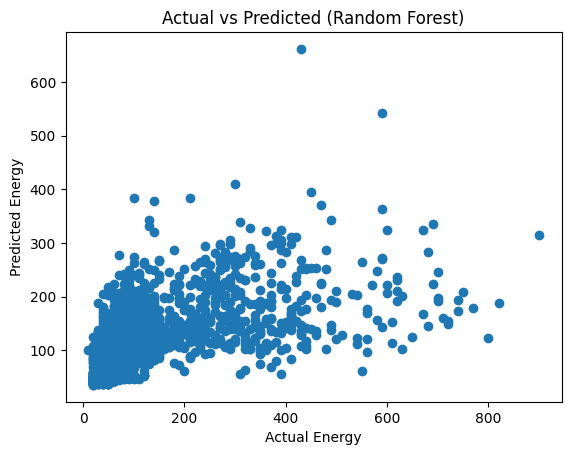

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

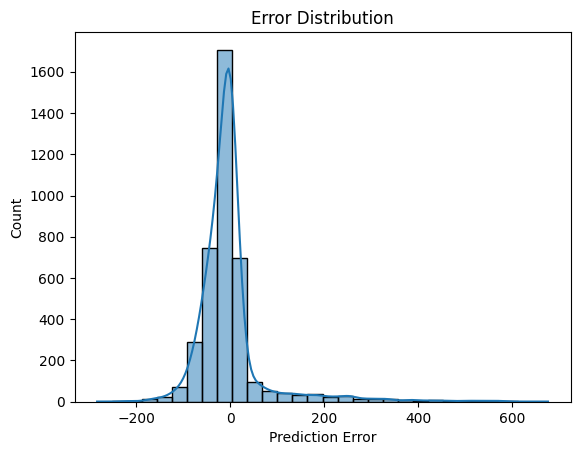

In [20]:
import seaborn as sns

errors = y_test - y_pred_rf

sns.histplot(errors, bins=30, kde=True)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

import pickle

with open("energy_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [29]:
import pickle

with open("energy_model.pkl", "wb") as f:
    pickle.dump((rf, rf.feature_names_in_), f)

with open("energy_model.pkl", "rb") as f:
    model = pickle.load(f)


In [30]:
with open("energy_model.pkl", "rb") as f:
    model, feature_order = pickle.load(f)

Sample Prediction for testing

In [25]:
print(model.feature_names_in_)

['T6' 'T3' 'lights' 'Press_mm_hg' 'T_out' 'RH_1' 'RH_8' 'T2' 'hour'
 'RH_out' 'Windspeed' 'RH_3' 'RH_5']


In [28]:
import pandas as pd

# Single input
sample_input = pd.DataFrame([{
    'T6': 18,
    'T3': 21,
    'lights': 10,
    'Press_mm_hg': 755,
    'T_out': 20,
    'RH_1': 45,
    'RH_8': 42,
    'T2': 22,
    'hour': 14,
    'RH_out': 50,
    'Windspeed': 5,
    'RH_3': 44,
    'RH_5': 40
}])

prediction = model.predict(sample_input)
print("Predicted Energy Consumption:", prediction[0])

Predicted Energy Consumption: 321.0149334487316


In [27]:
import pandas as pd

# Multiple inputs
test_inputs = pd.DataFrame([
    {
        'T6': 20, 'T3': 23, 'lights': 20, 'Press_mm_hg': 760, 'T_out': 25,
        'RH_1': 48, 'RH_8': 40, 'T2': 24, 'hour': 10, 'RH_out': 55,
        'Windspeed': 3, 'RH_3': 43, 'RH_5': 42
    },
    {
        'T6': 26, 'T3': 27, 'lights': 40, 'Press_mm_hg': 750, 'T_out': 30,
        'RH_1': 55, 'RH_8': 48, 'T2': 28, 'hour': 18, 'RH_out': 60,
        'Windspeed': 6, 'RH_3': 52, 'RH_5': 50
    }
])

predictions = model.predict(test_inputs)
print("Predictions:", predictions)

Predictions: [284.48897864 271.2899628 ]
